In [1]:
# =========================================================
# PORTFOLIO OPTIMIZATION OBJECTIVE
# =========================================================
#
# Objective:
# Minimize portfolio volatility subject to:
#
# - Full capital allocation
#   Σ(weights) = 1
#
# - Long-only portfolio
#   0 <= weights <= 1
#
# Optimization Method:
# Sequential Least Squares Programming (SLSQP)
#
# =========================================================

In [2]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yfin

from scipy.optimize import minimize

pd.options.display.float_format = "{:,.6f}".format

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# =========================================================
# STARTING + END DATES
# =========================================================

end = datetime.date.today()
start = "2024-01-01"

ticker_A = ['AAPL','MSFT','JPM','XOM','UNH','PG','HD','CAT']
ticker_B = ['AAPL','MSFT','JNJ','JPM','XOM','PG','KO','PEP']

In [5]:
# =========================================================
# DOWNLOAD DATA
# =========================================================

def download_data(start, end, tickers):
    
    df = yfin.download(
        tickers,
        start,
        end,
        auto_adjust=False
    )["Adj Close"]

    # convert index to timezone-aware
    df.index = df.index.tz_localize('UTC')

    return df

#portfolio_A = pd.read_csv("/data/portfolio_A.csv", index=True)
#portfolio_B = pd.read_csv("/data/portfolio_A.csv", index=True)

portfolio_A = download_data(start, end, ticker_A)
portfolio_B = download_data(start, end, ticker_B)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [6]:
# =========================================================
# ASSET PRICE HISTORY VISUALIZATION
# =========================================================

def display_price_history(df, assets, from_, to_, name):

    fig = plt.figure(figsize=(14,7))
    ax = fig.add_subplot(111)

    df.loc[from_:to_, assets].plot(ax=ax)

    ax.set_title(f"{name} Historical Asset Price Performance")
    ax.set_ylabel("Adjusted Closing Price")
    ax.set_xlabel("Date")

    ax.legend(
        title="Assets",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.savefig("asset_price.jpg")

from_ = "2024-01-01"
to_ = "2026-05-01"

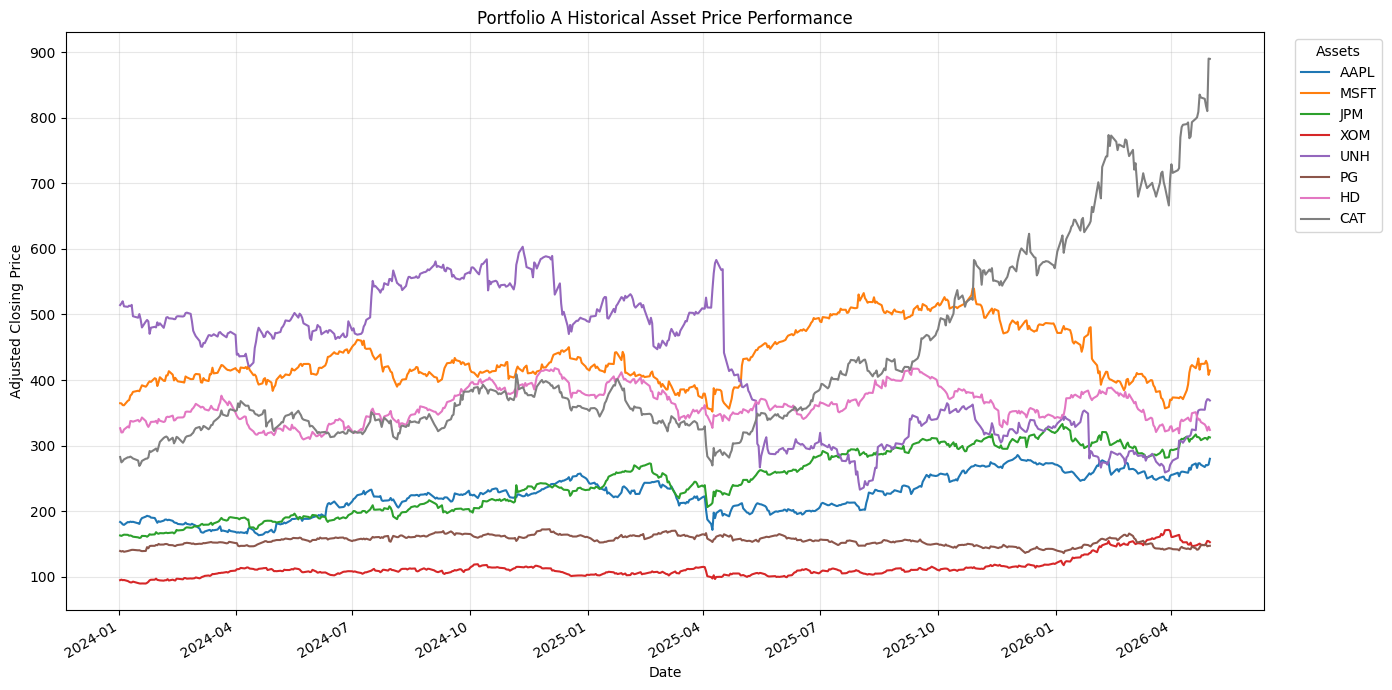

<Figure size 640x480 with 0 Axes>

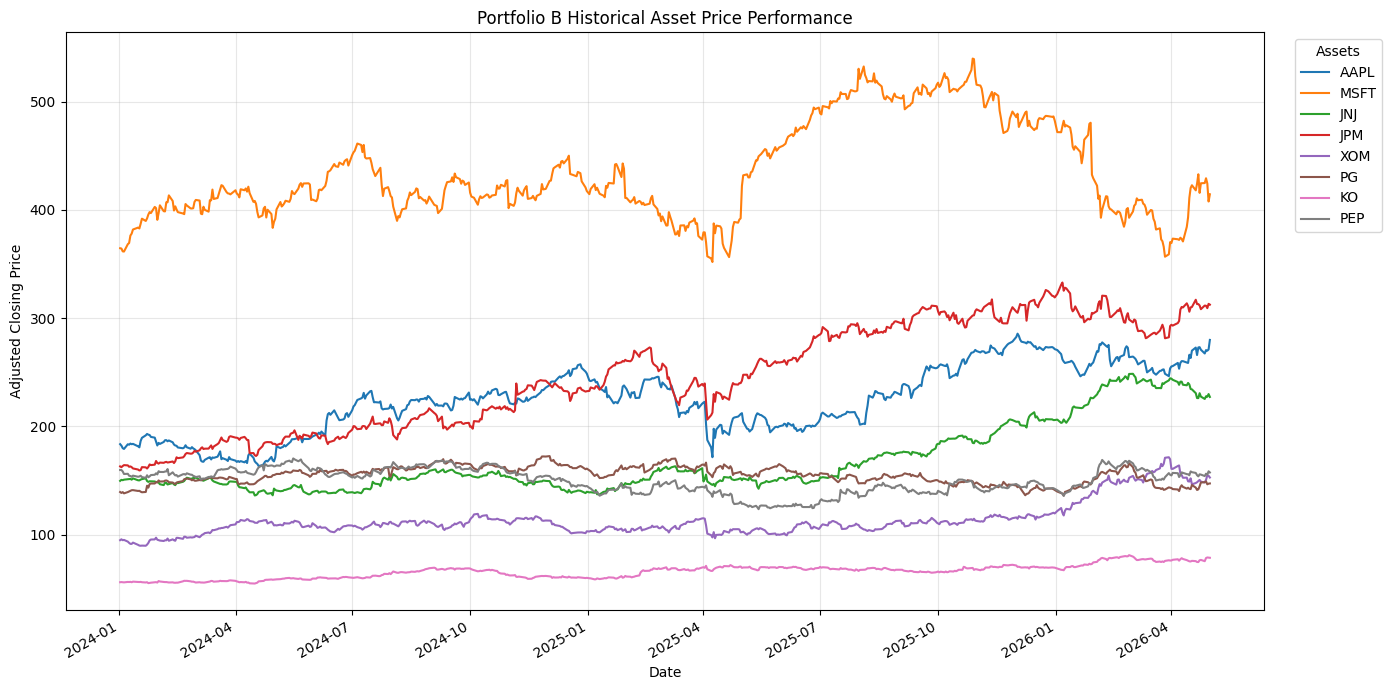

<Figure size 640x480 with 0 Axes>

In [7]:
display_price_history(portfolio_A, ticker_A, from_, to_, "Portfolio A")
display_price_history(portfolio_B, ticker_B, from_, to_, "Portfolio B")

In [8]:
# =========================================================
# DAILY RETURNS
# =========================================================

simple_stock_returns_A = portfolio_A.dropna().pct_change()[1:]
simple_stock_returns_B = portfolio_B.dropna().pct_change()[1:]

log_stock_returns_A = np.log(
    portfolio_A / portfolio_A.shift(1)
)[1:]

log_stock_returns_B = np.log(
    portfolio_B / portfolio_B.shift(1)
)[1:]

In [9]:
# =========================================================
# TOTAL SIMPLE RETURNS
# =========================================================

print("Portfolio A Simple Returns")

for tick in ticker_A:

    total_returns = (
        np.round(
            (1 + simple_stock_returns_A[tick]).prod() - 1,
            3
        ) * 100
    )

    print(f"{tick}_total_return = {total_returns}%")

print("\nPortfolio B Simple Returns")

for tick in ticker_B:

    total_returns = (
        np.round(
            (1 + simple_stock_returns_B[tick]).prod() - 1,
            3
        ) * 100
    )

    print(f"{tick}_total_return = {total_returns}%")

Portfolio A Simple Returns
AAPL_total_return = 60.6%
MSFT_total_return = 11.799999999999999%
JPM_total_return = 87.0%
XOM_total_return = 58.8%
UNH_total_return = -22.900000000000002%
PG_total_return = 3.3000000000000003%
HD_total_return = -4.9%
CAT_total_return = 222.8%

Portfolio B Simple Returns
AAPL_total_return = 60.6%
MSFT_total_return = 11.799999999999999%
JNJ_total_return = 49.8%
JPM_total_return = 87.0%
XOM_total_return = 58.8%
PG_total_return = 3.3000000000000003%
KO_total_return = 42.9%
PEP_total_return = -4.9%


In [10]:
# =========================================================
# TOTAL LOG RETURNS
# =========================================================

print("\nPortfolio A Log Returns")

for tick in ticker_A:

    total_returns = np.round(
        log_stock_returns_A[tick].sum() * 100,
        3
    )

    print(f"{tick}_total_return = {total_returns}%")

print("\nPortfolio B Log Returns")

for tick in ticker_B:

    total_returns = np.round(
        log_stock_returns_B[tick].sum() * 100,
        3
    )

    print(f"{tick}_total_return = {total_returns}%")


Portfolio A Log Returns
AAPL_total_return = 47.374%
MSFT_total_return = 11.193%
JPM_total_return = 62.611%
XOM_total_return = 46.256%
UNH_total_return = -26.034%
PG_total_return = 3.223%
HD_total_return = -5.023%
CAT_total_return = 117.175%

Portfolio B Log Returns
AAPL_total_return = 47.374%
MSFT_total_return = 11.193%
JNJ_total_return = 40.444%
JPM_total_return = 62.611%
XOM_total_return = 46.256%
PG_total_return = 3.223%
KO_total_return = 35.707%
PEP_total_return = -5.028%


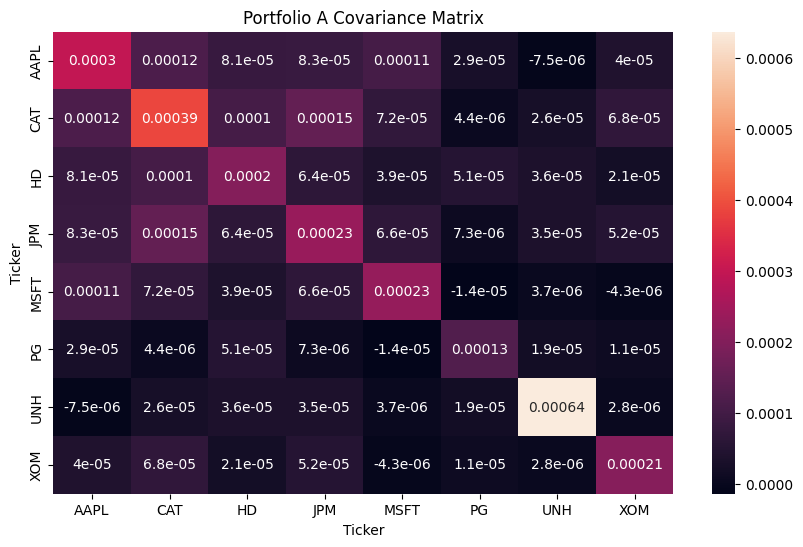

<Figure size 640x480 with 0 Axes>

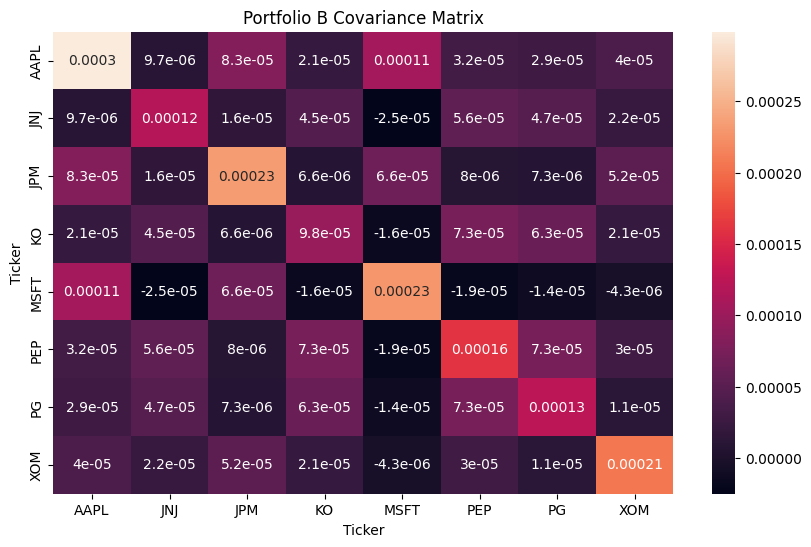

<Figure size 640x480 with 0 Axes>

In [11]:
# =========================================================
# COVARIANCE HEATMAPS
# =========================================================

plt.figure(figsize=(10,6))
sns.heatmap(simple_stock_returns_A.cov(), annot=True)
plt.title("Portfolio A Covariance Matrix")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(simple_stock_returns_B.cov(), annot=True)
plt.title("Portfolio B Covariance Matrix")
plt.show()


In [12]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

train_returns_A = simple_stock_returns_A.loc["2024":"2025"]
test_returns_A = simple_stock_returns_A.loc["2026":]

train_returns_B = simple_stock_returns_B.loc["2024":"2025"]
test_returns_B = simple_stock_returns_B.loc["2026":]


In [13]:
# =========================================================
# ANNUALIZED MEAN RETURNS
# =========================================================

def calculate_mean_returns(simple_stock_returns):

    return simple_stock_returns.mean() * 252


In [14]:
# =========================================================
# ANNUALIZED COVARIANCE MATRIX
# =========================================================

def calculate_covariance_matrix(simple_stock_returns):

    return simple_stock_returns.cov() * 252

mean_returns_A = calculate_mean_returns(train_returns_A)
cov_matrix_A = calculate_covariance_matrix(train_returns_A)

mean_returns_B = calculate_mean_returns(train_returns_B)
cov_matrix_B = calculate_covariance_matrix(train_returns_B)


In [15]:
# =========================================================
# PORTFOLIO RETURN
# =========================================================

def calculate_portfolio_return(weights, mean_returns):

    return np.dot(weights, mean_returns)

# =========================================================
# PORTFOLIO VOLATILITY
# =========================================================

def calculate_portfolio_volatility(weights, cov_matrix):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

In [16]:
# =========================================================
# OPTIMIZE PORTFOLIO WEIGHTS
# =========================================================

def optimize_portfolio_weights(mean_returns, cov_matrix):

    num_assets = len(mean_returns)

    # equal weight initialization
    initial_weights = np.ones(num_assets) / num_assets

    # weights must sum to 1
    constraints = ({
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    })

    # no short selling
    bounds = tuple((0, 1) for _ in range(num_assets))

    optimization = minimize(
        calculate_portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return optimization.x


In [17]:
optimal_weights_A = optimize_portfolio_weights(
    mean_returns_A,
    cov_matrix_A
)

optimal_weights_B = optimize_portfolio_weights(
    mean_returns_B,
    cov_matrix_B
)

In [18]:
# =========================================================
# DISPLAY OPTIMAL WEIGHTS
# =========================================================

def format_optimal_weights(optimal_weights, tickers):

    weights_dict = {}

    for i, ticker in enumerate(tickers):

        weights_dict[f"{ticker}_weight"] = np.round(
            optimal_weights[i],
            4
        )

    return weights_dict

optimal_weights_dict_A = format_optimal_weights(
    optimal_weights_A,
    ticker_A
)

optimal_weights_dict_B = format_optimal_weights(
    optimal_weights_B,
    ticker_B
)

print("\nPortfolio A Optimal Weights")
print(optimal_weights_dict_A)

print("\nPortfolio B Optimal Weights")
print(optimal_weights_dict_B)



Portfolio A Optimal Weights
{'AAPL_weight': 0.0, 'MSFT_weight': 0.0011, 'JPM_weight': 0.0651, 'XOM_weight': 0.0567, 'UNH_weight': 0.2273, 'PG_weight': 0.3906, 'HD_weight': 0.0635, 'CAT_weight': 0.1957}

Portfolio B Optimal Weights
{'AAPL_weight': 0.0, 'MSFT_weight': 0.1991, 'JNJ_weight': 0.0358, 'JPM_weight': 0.2463, 'XOM_weight': 0.2292, 'PG_weight': 0.0244, 'KO_weight': 0.1336, 'PEP_weight': 0.1317}


In [19]:
# =========================================================
# PORTFOLIO PERFORMANCE
# =========================================================

def calculate_optimal_portfolio_performance(
    optimal_weights,
    mean_returns,
    cov_matrix
):

    port_return = calculate_portfolio_return(
        optimal_weights,
        mean_returns
    )

    port_volatility = calculate_portfolio_volatility(
        optimal_weights,
        cov_matrix
    )

    return {
        "expected_return": np.round(port_return, 4),
        "volatility": np.round(port_volatility, 4)
    }

optimal_portfolio_performance_A = (
    calculate_optimal_portfolio_performance(
        optimal_weights_A,
        mean_returns_A,
        cov_matrix_A
    )
)

optimal_portfolio_performance_B = (
    calculate_optimal_portfolio_performance(
        optimal_weights_B,
        mean_returns_B,
        cov_matrix_B
    )
)

print("\nPortfolio A Performance")
print(optimal_portfolio_performance_A)

print("\nPortfolio B Performance")
print(optimal_portfolio_performance_B)


Portfolio A Performance
{'expected_return': 0.0881, 'volatility': 0.1144}

Portfolio B Performance
{'expected_return': 0.1358, 'volatility': 0.1026}


In [20]:
# =========================================================
# APPLY TRAINED WEIGHTS TO TEST DATA
# =========================================================

def calculate_portfolio_returns(
    simple_stock_returns,
    optimal_weights
):

    return simple_stock_returns @ optimal_weights

portfolio_returns_A = calculate_portfolio_returns(
    test_returns_A,
    optimal_weights_A
)

portfolio_returns_B = calculate_portfolio_returns(
    test_returns_B,
    optimal_weights_B
)

In [21]:
# =========================================================
# PORTFOLIO GROWTH
# =========================================================

def calculate_portfolio_growth(portfolio_returns):

    return (1 + portfolio_returns).cumprod()

portfolio_growth_A = calculate_portfolio_growth(
    portfolio_returns_A
)

portfolio_growth_B = calculate_portfolio_growth(
    portfolio_returns_B
)

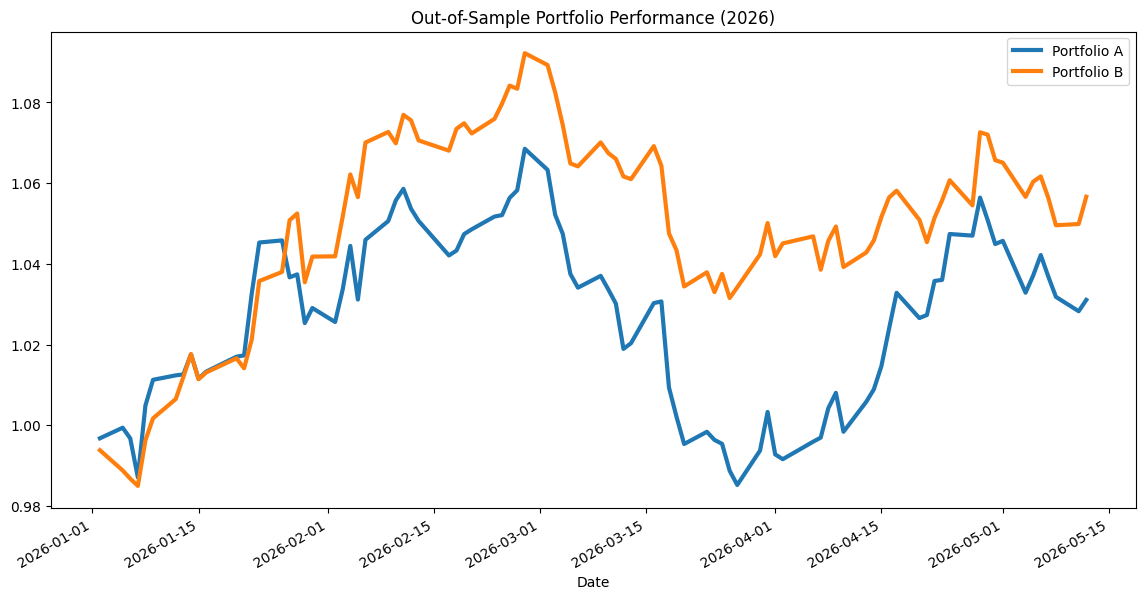

<Figure size 640x480 with 0 Axes>

In [22]:
# =========================================================
# DISPLAY PORTFOLIOS
# =========================================================

def display_portfolios(
    portfolio_growth_A,
    portfolio_growth_B
):

    fig, ax = plt.subplots(figsize=(14,7))

    portfolio_growth_A.plot(
        ax=ax,
        linewidth=3,
        label="Portfolio A"
    )

    portfolio_growth_B.plot(
        ax=ax,
        linewidth=3,
        label="Portfolio B"
    )

    ax.set_title(
        "Out-of-Sample Portfolio Performance (2026)"
    )
    ax.legend()
    plt.show()

display_portfolios(
    portfolio_growth_A,
    portfolio_growth_B
)

In [29]:
# =========================================================
# PORTFOLIO METRICS
# =========================================================

def portfolio_metrics(portfolio_returns):

    annual_return = (
        np.prod(1 + portfolio_returns)
        ** (252 / len(portfolio_returns))
        - 1
    )

    volatility = (
        portfolio_returns.std()
        * np.sqrt(252)
    )

    sharpe = annual_return / volatility

    return {
        "return": round(annual_return, 4),
        "volatility": round(volatility, 4),
        "sharpe": round(sharpe, 4)
    }

metrics_A = portfolio_metrics(portfolio_returns_A)
metrics_B = portfolio_metrics(portfolio_returns_B)

print("\nPortfolio A Test Metrics")
print(metrics_A)

print("\nPortfolio B Test Metrics")
print(metrics_B)


Portfolio A Test Metrics
{'return': 0.0894, 'volatility': 0.112, 'sharpe': 0.798}

Portfolio B Test Metrics
{'return': 0.1668, 'volatility': 0.1007, 'sharpe': 1.6559}


In [24]:
def display_risk_return_comparison(returns_data, portfolio_returns, portfolio_name):
    # assets & portfolio volatility
    portfolio_volatility = portfolio_returns.std()
    asset_volatility = returns_data.std()

    # portfolio & total asset returns
    asset_total_returns = ((1 + returns_data).prod() - 1)
    portfolio_total_return = ((1 + portfolio_returns).prod() - 1)
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16,5))

    # =========================================
    # VOLATILITY COMPARISON
    # =========================================

    ax1.bar(x=returns_data.columns, height=asset_volatility, alpha=0.7)
    ax1.hlines(
        y=portfolio_volatility,
        xmin=-0.5,
        xmax=len(returns_data.columns)-0.5,
        linestyle="--",
        color="red",
        alpha=0.8,
        label="Portfolio Volatility"
    )

    ax1.set_title(f"{portfolio_name} Assets vs Portfolio Volatility")
    ax1.set_ylabel("Volatility")
    ax1.legend()

    # =========================================
    # TOTAL RETURN COMPARISON
    # =========================================

    ax2.bar(x=returns_data.columns, height=asset_total_returns, alpha=0.7)
    ax2.hlines(
        y=portfolio_total_return,
        xmin=-0.5,
        xmax=len(returns_data.columns)-0.5,
        linestyle="--",
        color="red",
        alpha=0.8,
        label="Portfolio Total Return")

    ax2.set_title(f"{portfolio_name} Assets vs Portfolio Returns")
    ax2.set_ylabel("Total Return")
    ax2.legend()
    plt.show()

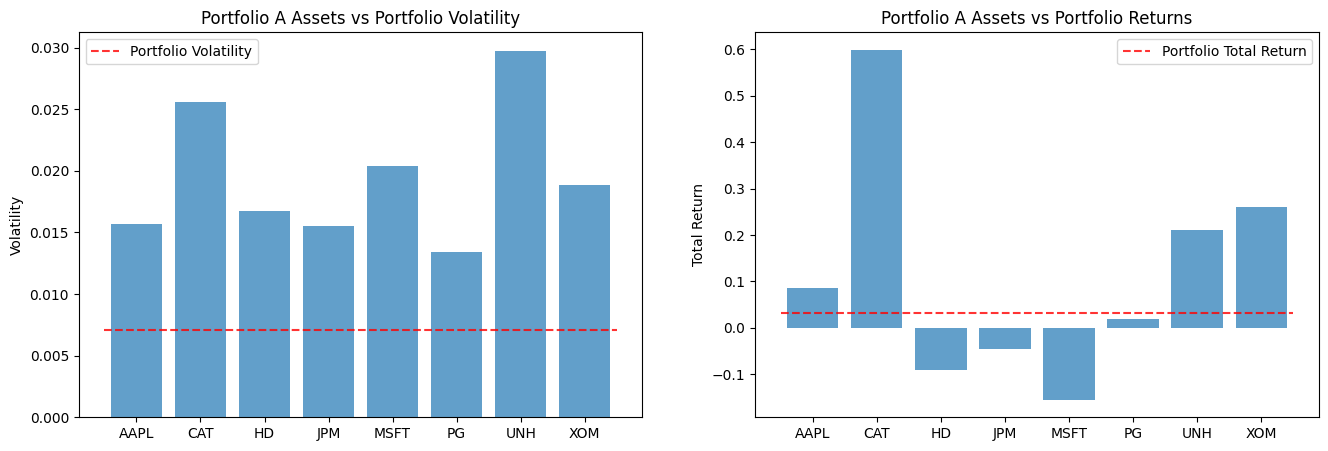

<Figure size 640x480 with 0 Axes>

In [25]:
display_risk_return_comparison(
    test_returns_A,
    portfolio_returns_A,
    "Portfolio A"
)

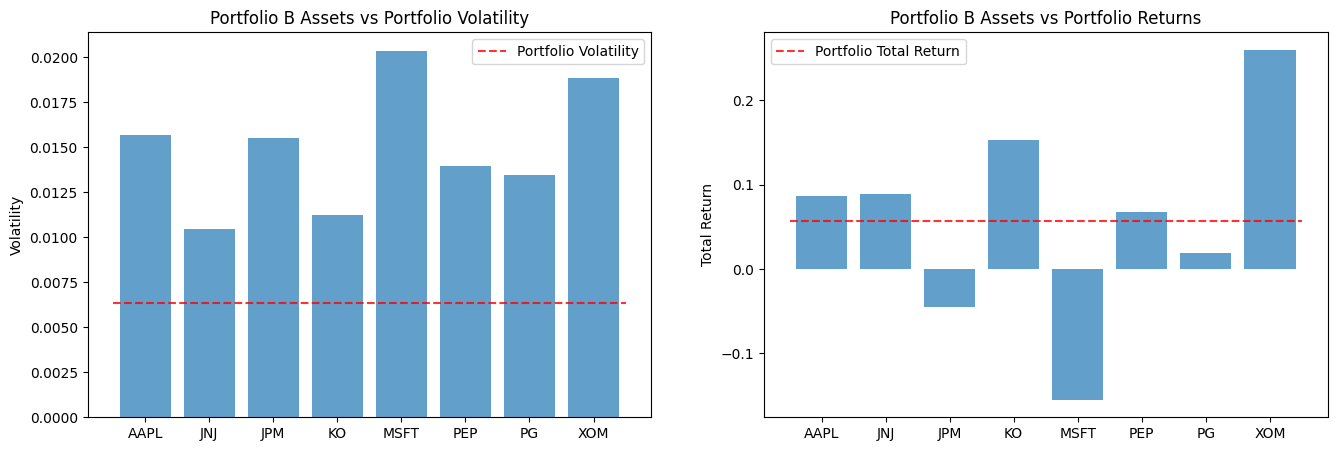

<Figure size 640x480 with 0 Axes>

In [26]:
display_risk_return_comparison(
    test_returns_B,
    portfolio_returns_B,
    "Portfolio B"
)

In [31]:
# =========================================================
# PERFORMANCE INSIGHTS
# =========================================================
#
# The out-of-sample portfolio evaluation highlights a
# significant difference in risk-adjusted performance
# between Portfolio A and Portfolio B.
#
# Portfolio B achieved a substantially higher annualized
# return of approximately 16.68% compared to Portfolio A's
# 8.94%, while simultaneously maintaining lower portfolio
# volatility.
#
# This improvement is reflected in the Sharpe Ratio, where
# Portfolio B recorded a value of 1.66 versus 0.80 for
# Portfolio A. The higher Sharpe Ratio indicates that
# Portfolio B generated superior returns per unit of risk
# undertaken.
#
# From a portfolio construction perspective, these results
# suggest that Portfolio B achieved more efficient asset
# diversification and risk allocation during the test
# period. The portfolio composition appears to have
# benefited from stronger return stability and more
# favorable covariance relationships among constituent
# assets.
#
# In contrast, Portfolio A exhibited weaker risk-adjusted
# efficiency, implying that the portfolio assumed higher
# volatility without a proportional increase in returns.
#
# Overall, the analysis demonstrates the importance of
# portfolio composition and covariance structure in
# determining long-term portfolio efficiency under a
# mean-variance optimization framework.
# =========================================================